# Joint Angle Peak 검증 시각화

preprocess 결과 검증을 위해 특정 ID/속도의 joint angle 시계열에 대해:

- stance phase(contact==1) 구간을 반투명 초록색으로 표시
- IQR 통과 피크를 파란색 점으로 표시
- 피크로 탐지되었지만 IQR에서 탈락(또는 피크 수 부족으로 평균 계산 제외)한 포인트를 노란색 점으로 표시

함수화해서 여러 ID에도 반복 적용할 수 있게 구성합니다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import pyarrow.compute as pc
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from IPython.display import display

cwd = Path.cwd()
project_root = cwd if (cwd / "AGENTS.md").exists() else cwd.parent
print("CWD:", cwd)
print("PROJECT_ROOT:", project_root)

PATH_RAW = project_root / "data/processed/raw_merged.parquet"
PATH_ID = project_root / "data/ID.csv"
PATH_ANALYSIS = project_root / "data/processed/analysis_data.csv"

assert PATH_RAW.exists(), f"raw parquet 없음: {PATH_RAW}"
assert PATH_ID.exists(), f"ID.csv 없음: {PATH_ID}"
assert PATH_ANALYSIS.exists(), f"analysis_data.csv 없음: {PATH_ANALYSIS}"

print("입력 파일 확인 완료")

CWD: /Users/ryutt/Desktop/mini_ryutt/Walking/notebooks
PROJECT_ROOT: /Users/ryutt/Desktop/mini_ryutt/Walking
입력 파일 확인 완료


In [2]:
SUBJECT_ID_ALIASES = {
    "ACLR38": "ACLR36",
}

JOINT_COLS = {
    "hip_flexion": ("jointAngle_42", "jointAngle_54"),
    "hip_adduction": ("jointAngle_43", "jointAngle_55"),
    "hip_int_rotation": ("jointAngle_44", "jointAngle_56"),
    "knee_flexion": ("jointAngle_45", "jointAngle_57"),
    "knee_adduction": ("jointAngle_46", "jointAngle_58"),
    "knee_int_rotation": ("jointAngle_47", "jointAngle_59"),
    "ankle_dorsiflexion": ("jointAngle_48", "jointAngle_60"),
    "ankle_adduction": ("jointAngle_49", "jointAngle_61"),
    "ankle_int_rotation": ("jointAngle_50", "jointAngle_62"),
}

FOOT_CONTACT_COLS = {
    "Right": "footContacts_2",
    "Left": "footContacts_0",
}

PEAK_DIRECTION = {
    "hip_flexion": "max",
    "hip_adduction": "min",
    "hip_int_rotation": "max",
    "knee_flexion": "max",
    "knee_adduction": "min",
    "knee_int_rotation": "max",
    "ankle_dorsiflexion": "max",
    "ankle_adduction": "min",
    "ankle_int_rotation": "max",
}

print("상수 정의 완료")

상수 정의 완료


In [3]:
def get_stance_segments(contact_signal: np.ndarray):
    contact_binary = np.asarray(contact_signal, dtype=int)
    segments = []
    seg_start = None

    for idx, val in enumerate(contact_binary):
        if val == 1 and seg_start is None:
            seg_start = idx
        elif val != 1 and seg_start is not None:
            segments.append((seg_start, idx))
            seg_start = None

    if seg_start is not None:
        segments.append((seg_start, len(contact_binary)))

    return segments


def detect_peaks_with_iqr(
    signal: np.ndarray,
    direction: str,
    contact_signal: np.ndarray,
    distance: int = 50,
    prominence: float = 1.0,
    iqr_lower_bound: float = 1.5,
    iqr_upper_bound: float = 2.5,
    peak_method: str = "argextrema",
    butter_order: int = 2,
    butter_cutoff: float = 0.1,
):
    result = {
        "all_peaks": np.array([], dtype=int),
        "valid_peaks": np.array([], dtype=int),
        "rejected_peaks": np.array([], dtype=int),
        "q1": np.nan,
        "q3": np.nan,
        "iqr": np.nan,
        "lower_threshold": np.nan,
        "upper_threshold": np.nan,
        "reason": "",
        "mean_valid_peak": np.nan,
    }

    if len(signal) < distance * 2:
        result["reason"] = "signal_too_short"
        return result

    if contact_signal is None or len(contact_signal) != len(signal):
        result["reason"] = "invalid_contact_signal"
        return result

    stance_idx = np.where(contact_signal == 1)[0]
    if len(stance_idx) < distance * 2:
        result["reason"] = "stance_too_short"
        return result

    if peak_method == "argextrema":
        peaks = []
        for seg_start, seg_end in get_stance_segments(contact_signal):
            if seg_end <= seg_start:
                continue
            seg = signal[seg_start:seg_end]
            if len(seg) == 0:
                continue
            local_idx = int(np.argmax(seg)) if direction == "max" else int(np.argmin(seg))
            peaks.append(seg_start + local_idx)
        peaks = np.asarray(peaks, dtype=int)

    elif peak_method == "butterworth":
        stance_signal = signal[stance_idx]
        filtered_stance_signal = stance_signal
        try:
            if 0 < butter_cutoff < 1:
                b, a = butter(butter_order, butter_cutoff, btype="low")
                pad_len = 3 * (max(len(a), len(b)) - 1)
                if len(stance_signal) > pad_len:
                    filtered_stance_signal = filtfilt(b, a, stance_signal)
        except ValueError:
            filtered_stance_signal = stance_signal

        if direction == "max":
            local_peaks, _ = find_peaks(filtered_stance_signal, distance=distance, prominence=prominence)
        else:
            local_peaks, _ = find_peaks(-filtered_stance_signal, distance=distance, prominence=prominence)

        peaks = stance_idx[local_peaks] if len(local_peaks) > 0 else np.array([], dtype=int)

    else:
        raise ValueError(f"지원하지 않는 peak_method: {peak_method}")

    result["all_peaks"] = peaks

    if len(peaks) == 0:
        result["reason"] = "no_peaks"
        return result

    target_signal = signal if direction == "max" else -signal

    if len(peaks) >= 4:
        peak_heights = target_signal[peaks]
        q1 = np.percentile(peak_heights, 25)
        q3 = np.percentile(peak_heights, 75)
        iqr = q3 - q1
        lower_threshold = q1 - (iqr_lower_bound * iqr)
        upper_threshold = q3 + (iqr_upper_bound * iqr)

        valid_mask = (target_signal[peaks] >= lower_threshold) & (target_signal[peaks] <= upper_threshold)
        valid_peaks = peaks[valid_mask]
        rejected_peaks = peaks[~valid_mask]

        result["valid_peaks"] = valid_peaks
        result["rejected_peaks"] = rejected_peaks
        result["q1"] = q1
        result["q3"] = q3
        result["iqr"] = iqr
        result["lower_threshold"] = lower_threshold
        result["upper_threshold"] = upper_threshold
        result["reason"] = "ok" if len(valid_peaks) > 0 else "all_filtered_by_iqr"

        if len(valid_peaks) > 0:
            result["mean_valid_peak"] = float(np.mean(signal[valid_peaks]))

    else:
        result["valid_peaks"] = np.array([], dtype=int)
        result["rejected_peaks"] = peaks
        result["reason"] = "too_few_peaks_for_iqr"

    return result

In [4]:
def _canonical_subject_id(subject_id: str) -> str:
    return SUBJECT_ID_ALIASES.get(subject_id, subject_id)


def _subject_candidates_for_raw(subject_id: str) -> list:
    canonical = _canonical_subject_id(subject_id)
    candidates = [canonical]
    alias_sources = [src for src, canon in SUBJECT_ID_ALIASES.items() if canon == canonical]
    for src in alias_sources:
        if src not in candidates:
            candidates.append(src)
    if subject_id not in candidates:
        candidates.append(subject_id)
    return candidates


def load_subject_speed_timeseries(subject_id: str, speed: str) -> pd.DataFrame:
    speed = str(speed).strip().lower()
    subject_candidates = _subject_candidates_for_raw(subject_id)

    joint_raw_cols = list({col for pair in JOINT_COLS.values() for col in pair})
    cols = ["subject_id", "speed", "time_ms"] + joint_raw_cols + list(FOOT_CONTACT_COLS.values())
    cols = list(dict.fromkeys(cols))

    dataset = ds.dataset(PATH_RAW.as_posix(), format="parquet")
    filter_expr = pc.field("subject_id").isin(subject_candidates) & (pc.field("speed") == speed)
    table = dataset.to_table(columns=cols, filter=filter_expr)
    df = table.to_pandas()

    if df.empty:
        raise ValueError(f"원시 데이터 없음: subject_id={subject_id}, speed={speed}")

    df["subject_id"] = df["subject_id"].replace(SUBJECT_ID_ALIASES)
    df["time_ms"] = pd.to_numeric(df["time_ms"], errors="coerce")
    return df.sort_values("time_ms").reset_index(drop=True)


def load_id_table() -> pd.DataFrame:
    return pd.read_csv(PATH_ID)


def infer_injured_leg(subject_id: str, id_df: pd.DataFrame) -> str:
    canonical = _canonical_subject_id(subject_id)
    mask = id_df["ID"].isin([canonical, subject_id])
    rows = id_df.loc[mask, ["ID", "Injured leg"]]

    if not rows.empty:
        leg = rows["Injured leg"].iloc[0]
        if isinstance(leg, str) and leg in {"Right", "Left"}:
            return leg

    return "Right"

In [ ]:
def plot_joint_series_with_peaks(
    subject_id: str,
    speed: str = "normal",
    leg_mode: str = "injured",
    features: list | None = None,
    distance: int = 50,
    prominence: float = 1.0,
    iqr_lower: float = 1.5,
    iqr_upper: float = 2.5,
    peak_method: str = "argextrema",
    butter_order: int = 2,
    butter_cutoff: float = 0.1,
    max_cols: int = 3,
):
    id_df = load_id_table()
    canonical_id = _canonical_subject_id(subject_id)
    df = load_subject_speed_timeseries(canonical_id, speed)

    injured_leg = infer_injured_leg(canonical_id, id_df)
    leg_mode_lower = str(leg_mode).lower()
    if leg_mode_lower == "injured":
        target_leg = injured_leg
    elif leg_mode_lower == "contralateral":
        target_leg = "Left" if injured_leg == "Right" else "Right"
    elif leg_mode_lower in {"right", "left"}:
        target_leg = leg_mode_lower.capitalize()
    else:
        raise ValueError("leg_mode는 injured/contralateral/right/left 중 하나여야 합니다.")

    selected_features = list(JOINT_COLS.keys()) if features is None else features
    n_features = len(selected_features)
    ncols = min(max_cols, n_features)
    nrows = int(np.ceil(n_features / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(30 * ncols, 6 * nrows), squeeze=False)
    flat_axes = axes.flatten()

    summary_rows = []

    for i, feat in enumerate(selected_features):
        ax = flat_axes[i]
        right_col, left_col = JOINT_COLS[feat]
        signal_col = right_col if target_leg == "Right" else left_col
        contact_col = FOOT_CONTACT_COLS[target_leg]
        direction = PEAK_DIRECTION[feat]

        signal_raw = pd.to_numeric(df[signal_col], errors="coerce").to_numpy(dtype=float)
        contact_signal = pd.to_numeric(df[contact_col], errors="coerce").fillna(0).to_numpy(dtype=int)

        if np.isnan(signal_raw).any():
            fill_val = np.nanmedian(signal_raw)
            if np.isnan(fill_val):
                fill_val = 0.0
            signal_for_peak = np.where(np.isnan(signal_raw), fill_val, signal_raw)
        else:
            signal_for_peak = signal_raw

        x = pd.to_numeric(df["time_ms"], errors="coerce").to_numpy(dtype=float)
        if np.isnan(x).all():
            x = np.arange(len(df), dtype=float)
            x_label = "frame_index"
        else:
            x_label = "time_ms"

        peak_result = detect_peaks_with_iqr(
            signal=signal_for_peak,
            direction=direction,
            contact_signal=contact_signal,
            distance=distance,
            prominence=prominence,
            iqr_lower_bound=iqr_lower,
            iqr_upper_bound=iqr_upper,
            peak_method=peak_method,
            butter_order=butter_order,
            butter_cutoff=butter_cutoff,
        )

        stance_segments = get_stance_segments(contact_signal)

        ax.plot(x, signal_raw, color="black", linewidth=1.2, label=f"{feat} ({target_leg})")

        for seg_start, seg_end in stance_segments:
            if seg_end <= seg_start:
                continue
            ax.axvspan(x[seg_start], x[seg_end - 1], color="green", alpha=0.14)

        valid_peaks = peak_result["valid_peaks"]
        rejected_peaks = peak_result["rejected_peaks"]

        if len(valid_peaks) > 0:
            ax.scatter(
                x[valid_peaks],
                signal_raw[valid_peaks],
                color="#1f77b4",
                s=26,
                zorder=5,
                label="valid peaks",
            )

        if len(rejected_peaks) > 0:
            ax.scatter(
                x[rejected_peaks],
                signal_raw[rejected_peaks],
                color="#f2c500",
                edgecolor="#8a6d00",
                linewidth=0.5,
                s=30,
                zorder=5,
                label="IQR rejected / insufficient",
            )

        title = (
            f"{feat} | dir={direction} | all={len(peak_result['all_peaks'])} | "
            f"valid={len(valid_peaks)} | reject={len(rejected_peaks)}"
        )
        ax.set_title(title, fontsize=10)
        ax.set_xlabel(x_label)
        ax.set_ylabel("joint angle")
        ax.grid(alpha=0.25, linestyle="--")

        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        if unique:
            ax.legend(unique.values(), unique.keys(), fontsize=8, loc="best")

        summary_rows.append(
            {
                "subject_id": canonical_id,
                "speed": str(speed).lower(),
                "feature": feat,
                "leg": target_leg,
                "signal_col": signal_col,
                "contact_col": contact_col,
                "all_peaks": len(peak_result["all_peaks"]),
                "valid_peaks": len(valid_peaks),
                "rejected_peaks": len(rejected_peaks),
                "reason": peak_result["reason"],
                "mean_valid_peak": peak_result["mean_valid_peak"],
            }
        )

    for j in range(n_features, len(flat_axes)):
        flat_axes[j].axis("off")

    fig.suptitle(
        f"subject={canonical_id} | speed={str(speed).lower()} | leg={target_leg} | method={peak_method}",
        fontsize=14,
    )
    fig.tight_layout()

    summary_df = pd.DataFrame(summary_rows)
    return df, summary_df, fig


def plot_joint_series_for_ids(subject_ids: list, speed: str = "normal", **kwargs):
    outputs = {}
    for sid in subject_ids:
        df, summary_df, _ = plot_joint_series_with_peaks(subject_id=sid, speed=speed, **kwargs)
        print(f"\n===== subject_id={sid}, speed={speed} =====")
        display(summary_df)
        plt.show()
        outputs[sid] = {
            "timeseries": df,
            "summary": summary_df,
        }
    return outputs

rows=4023


,subject_id,speed,feature,leg,signal_col,contact_col,all_peaks,valid_peaks,rejected_peaks,reason,mean_valid_peak
0,ACLD12,normal,hip_flexion,Right,jointAngle_42,footContacts_2,35,33,2,ok,3.205430
1,ACLD12,normal,hip_adduction,Right,jointAngle_43,footContacts_2,35,32,3,ok,-5.814760
2,ACLD12,normal,hip_int_rotation,Right,jointAngle_44,footContacts_2,35,31,4,ok,26.091651
3,ACLD12,normal,knee_flexion,Right,jointAngle_45,footContacts_2,35,35,0,ok,1.519368
4,ACLD12,normal,knee_adduction,Right,jointAngle_46,footContacts_2,35,35,0,ok,-4.394104
5,ACLD12,normal,knee_int_rotation,Right,jointAngle_47,footContacts_2,35,33,2,ok,16.160691
6,ACLD12,normal,ankle_dorsiflexion,Right,jointAngle_48,footContacts_2,35,30,5,ok,5.741798
7,ACLD12,normal,ankle_adduction,Right,jointAngle_49,footContacts_2,35,32,3,ok,-11.887205
8,ACLD12,normal,ankle_int_rotation,Right,jointAngle_50,footContacts_2,35,34,1,ok,12.529690


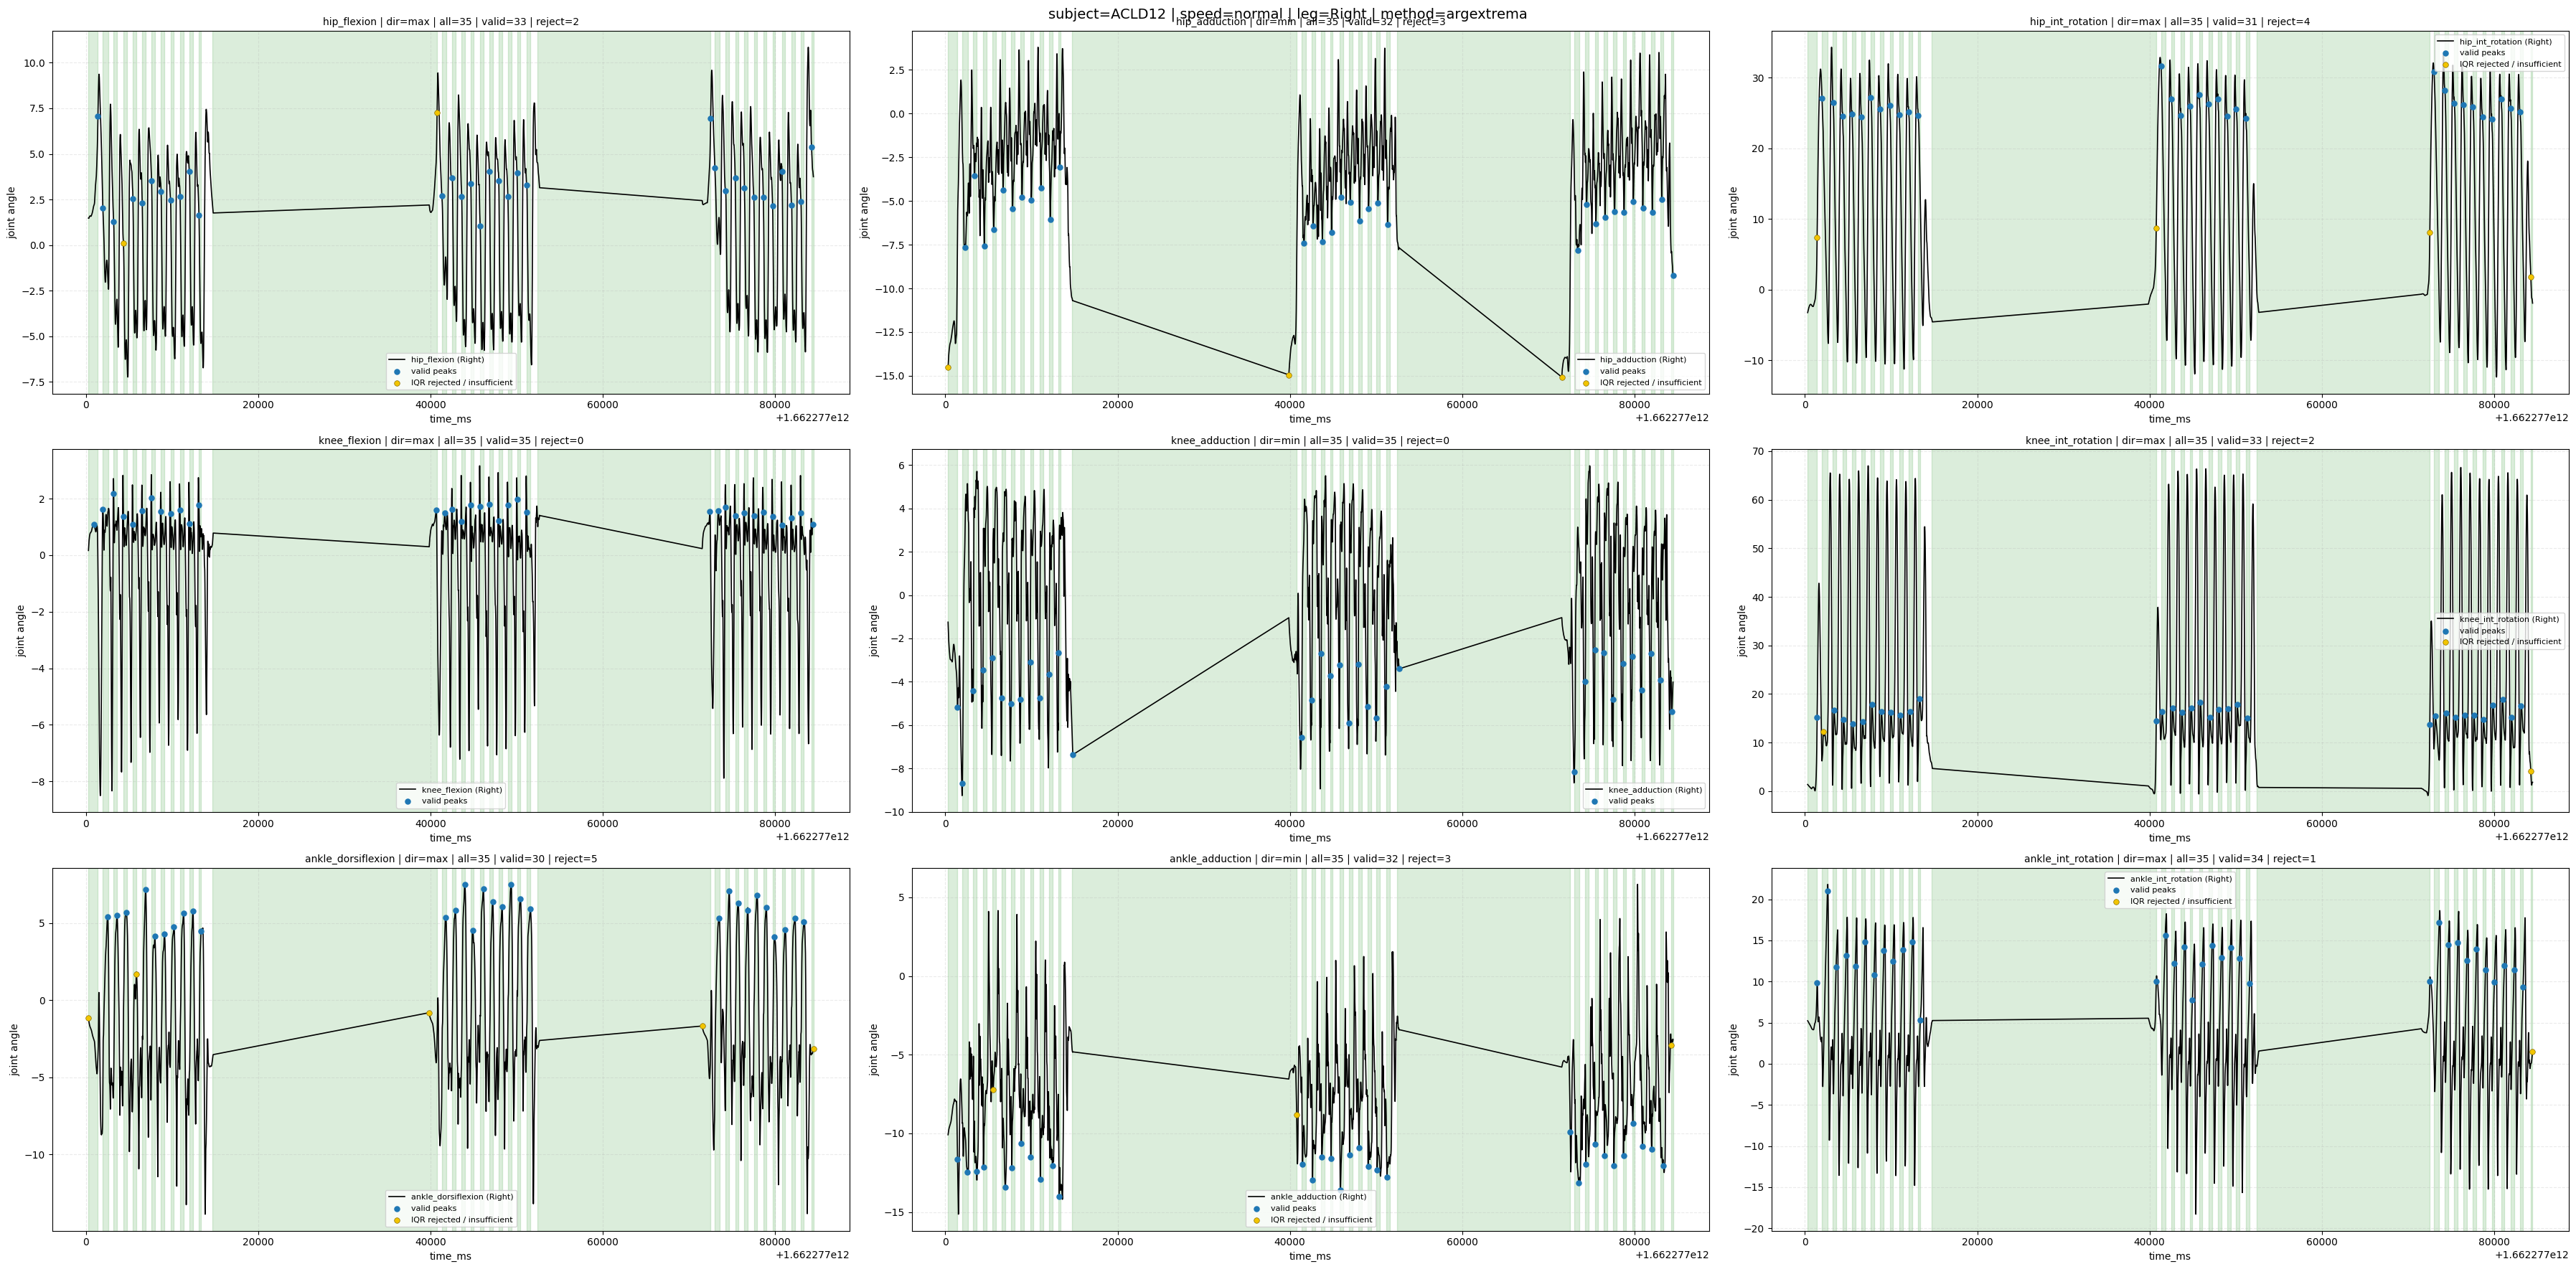

In [6]:
# 예시: 특정 ID + 특정 속도에서 모든 joint feature를 시각화
# 필요 시 target_id, target_speed, leg_mode를 바꿔서 실행하세요.

target_id = "ACLD12"
target_speed = "normal"

df_ts, summary_df, _ = plot_joint_series_with_peaks(
    subject_id=target_id,
    speed=target_speed,
    leg_mode="injured",
    peak_method="argextrema",
    distance=50,
    prominence=1.0,
    iqr_lower=1.5,
    iqr_upper=2.5,
)

print(f"rows={len(df_ts)}")
display(summary_df)

# 여러 ID를 반복 실행하고 싶으면 아래 예시를 사용
# outputs = plot_joint_series_for_ids(["ACLD12", "ACLD14"], speed="normal", leg_mode="injured")